In [1]:
%pip install torch torchtext spacy datasets portalocker
!python3 -m spacy download en_core_web_sm
!python3 -m spacy download de_core_news_sm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 43.6 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


2025-11-25 09:03:45.946903: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-25 09:03:49.464104: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 48.9 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


2025-11-25 09:04:08.921917: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-25 09:04:09.698281: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
import spacy
import math
import os
import random
import numpy as np
import time

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

2025-11-25 09:04:21.570972: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-25 09:04:22.314970: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Using device: cuda


In [3]:
from torchtext.vocab import build_vocab_from_iterator
dataset = load_dataset("bentrevett/multi30k")

spacy_de = spacy.load('de_core_news_sm')
spacy_en = spacy.load('en_core_web_sm')

def tokenize_de(text):
    return [tok.text for tok in spacy_de.tokenizer(text)]

def tokenize_en(text):
    return [tok.text for tok in spacy_en.tokenizer(text)]

def yield_tokens(data_iter, tokenizer, language):
    for example in data_iter:
        yield tokenizer(example[language])

SRC_LANGUAGE = 'de'
TGT_LANGUAGE = 'en'
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ['<unk>', '<pad>', '<sos>', '<eos>']

print("Building vocabularies...")
vocab_src = build_vocab_from_iterator(
    yield_tokens(dataset['train'], tokenize_de, SRC_LANGUAGE),
    min_freq=2,
    specials=special_symbols,
    special_first=True
)
vocab_src.set_default_index(UNK_IDX)

vocab_tgt = build_vocab_from_iterator(
    yield_tokens(dataset['train'], tokenize_en, TGT_LANGUAGE),
    min_freq=2,
    specials=special_symbols,
    special_first=True
)
vocab_tgt.set_default_index(UNK_IDX)

print(f"Vocab Source size: {len(vocab_src)}")
print(f"Vocab Target size: {len(vocab_tgt)}")

Building vocabularies...
Vocab Source size: 8014
Vocab Target size: 6191


In [4]:
from torch.nn.utils.rnn import pad_sequence

def text_transform(tokenizer, vocab, text):
    return [vocab[token] for token in tokenizer(text)]

def collate_batch(batch):
    src_batch, tgt_batch = [], []
    
    for item in batch:
        src_sample = item[SRC_LANGUAGE]
        tgt_sample = item[TGT_LANGUAGE]
        
        src_tokens = text_transform(tokenize_de, vocab_src, src_sample)
        tgt_tokens = text_transform(tokenize_en, vocab_tgt, tgt_sample)
        
        src_batch.append(torch.tensor([BOS_IDX] + src_tokens + [EOS_IDX], dtype=torch.long))
        tgt_batch.append(torch.tensor([BOS_IDX] + tgt_tokens + [EOS_IDX], dtype=torch.long))
    
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX, batch_first=True)
    
    return src_batch, tgt_batch

BATCH_SIZE = 128

train_dataloader = data.DataLoader(dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
valid_dataloader = data.DataLoader(dataset['validation'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_dataloader = data.DataLoader(dataset['test'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

In [56]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, pe_type='original', dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        self.pe_type = pe_type
        
        if pe_type == 'original':
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
            div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
            pe = pe.unsqueeze(0)
            self.register_buffer('pe', pe)
            
        elif pe_type == 'learnable':
            self.pe = nn.Embedding(max_len, d_model)
            nn.init.normal_(self.pe.weight, mean=0, std=0.02)
            
    def forward(self, x):
        seq_len = x.size(1)
        
        if self.pe_type == 'original':
            x = x + self.pe[:, :seq_len]
        else:
            positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0)
            x = x + self.pe(positions)
            
        return self.dropout(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_head, dropout=0.1):
        super().__init__()
        assert d_model % n_head == 0
        
        self.d_k = d_model // n_head
        self.n_head = n_head
        
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([self.d_k])).to(device)
        
    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]
        
        Q = self.w_q(query).view(batch_size, -1, self.n_head, self.d_k).permute(0, 2, 1, 3)
        K = self.w_k(key).view(batch_size, -1, self.n_head, self.d_k).permute(0, 2, 1, 3)
        V = self.w_v(value).view(batch_size, -1, self.n_head, self.d_k).permute(0, 2, 1, 3)
        energy = torch.matmul(Q, K.permute(0, 1, 3, 2)) / self.scale
        
        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e10)
            
        attention = torch.softmax(energy, dim=-1)
        
        x = torch.matmul(self.dropout(attention), V)
        
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(batch_size, -1, self.n_head * self.d_k)
        
        return self.fc(x)

class PositionwiseFeedforward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        return self.fc2(self.dropout(self.relu(self.fc1(x))))

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_head, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_head, dropout)
        self.pff = PositionwiseFeedforward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        _x = x
        x = self.self_attn(x, x, x, mask)
        x = self.norm1(_x + self.dropout(x))
        _x = x
        x = self.pff(x)
        x = self.norm2(_x + self.dropout(x))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_head, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_head, dropout)
        self.enc_attn = MultiHeadAttention(d_model, n_head, dropout)
        self.pff = PositionwiseFeedforward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, enc_out, src_mask, trg_mask):
        _x = x
        x = self.self_attn(x, x, x, trg_mask)
        x = self.norm1(_x + self.dropout(x))
        _x = x
        x = self.enc_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(_x + self.dropout(x))
        _x = x
        x = self.pff(x)
        x = self.norm3(_x + self.dropout(x))
        return x

class Encoder(nn.Module):
    def __init__(self, input_dim, d_model, n_layers, n_head, d_ff, max_len, pe_type, dropout):
        super().__init__()
        self.tok_embedding = nn.Embedding(input_dim, d_model)
        self.pos_embedding = PositionalEncoding(d_model, max_len, pe_type, dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_head, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([d_model])).to(device)
        
    def forward(self, src, src_mask):
        x = self.tok_embedding(src) * self.scale
        x = self.pos_embedding(x)
        
        for layer in self.layers:
            x = layer(x, src_mask)
        return x

class Decoder(nn.Module):
    def __init__(self, output_dim, d_model, n_layers, n_head, d_ff, max_len, pe_type, dropout):
        super().__init__()
        self.tok_embedding = nn.Embedding(output_dim, d_model)
        self.pos_embedding = PositionalEncoding(d_model, max_len, pe_type, dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_head, d_ff, dropout) for _ in range(n_layers)])
        self.fc_out = nn.Linear(d_model, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([d_model])).to(device)
        
    def forward(self, trg, enc_out, src_mask, trg_mask):
        x = self.tok_embedding(trg) * self.scale
        x = self.pos_embedding(x)
        
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, trg_mask)
            
        return self.fc_out(x)

In [8]:
def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_checkpoint(model, optimizer, epoch, loss, filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    print(f"=> Saving checkpoint to {path}")
    state = {
        'epoch': epoch,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(state, path)

def load_checkpoint(model, optimizer, filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    if os.path.isfile(path):
        print(f"=> Loading checkpoint from {path}")
        checkpoint = torch.load(path)
        model.load_state_dict(checkpoint['state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        start_epoch = checkpoint['epoch'] + 1
        return start_epoch
    else:
        print(f"=> No checkpoint found at {path}")
        return 0

In [7]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, 
                 d_model=256, n_layers=3, n_head=8, d_ff=512, 
                 max_len=100, pe_type='original', dropout=0.1):
        super().__init__()
        
        self.encoder = Encoder(src_vocab_size, d_model, n_layers, n_head, d_ff, max_len, pe_type, dropout)
        self.decoder = Decoder(trg_vocab_size, d_model, n_layers, n_head, d_ff, max_len, pe_type, dropout)
        
        self.src_pad_idx = PAD_IDX
        self.trg_pad_idx = PAD_IDX
        
    def make_src_mask(self, src):
        mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        return mask
    
    def make_trg_mask(self, trg):
        trg_pad_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2)
        
        trg_len = trg.shape[1]
        trg_sub_mask = torch.tril(torch.ones((trg_len, trg_len), device=device)).bool()
        
        mask = trg_pad_mask & trg_sub_mask
        return mask

    def forward(self, src, trg):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)
        
        enc_src = self.encoder(src, src_mask)
        output = self.decoder(trg, enc_src, src_mask, trg_mask)
        return output

In [103]:
class TorchTransformer(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, 
                 d_model, n_layers, n_head, d_ff, 
                 max_len, pe_type, dropout):
        super().__init__()
        
        self.src_tok_emb = nn.Embedding(src_vocab_size, d_model)
        self.tgt_tok_emb = nn.Embedding(trg_vocab_size, d_model)
        
        self.pos_encoder = PositionalEncoding(d_model, max_len, pe_type, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_head,
            num_encoder_layers=n_layers,
            num_decoder_layers=n_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True 
        )
        
        self.fc_out = nn.Linear(d_model, trg_vocab_size)
        self.scale = torch.sqrt(torch.FloatTensor([d_model])).to(device)
        self.src_pad_idx = PAD_IDX
        self.trg_pad_idx = PAD_IDX

    def forward(self, src, trg):
        src_key_padding_mask = (src == self.src_pad_idx)
        tgt_key_padding_mask = (trg == self.trg_pad_idx)
        trg_len = trg.shape[1]
        tgt_mask = self.transformer.generate_square_subsequent_mask(trg_len).to(device)
        src_emb = self.src_tok_emb(src) * self.scale
        src_emb = self.pos_encoder(src_emb)
        
        tgt_emb = self.tgt_tok_emb(trg) * self.scale
        tgt_emb = self.pos_encoder(tgt_emb)
        output = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )
        
        return self.fc_out(output)

In [9]:
def train_epoch(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0
    
    for i, (src, trg) in enumerate(iterator):
        src, trg = src.to(device), trg.to(device)
        
        optimizer.zero_grad()
        output = model(src, trg[:, :-1])
        
        output_dim = output.shape[-1]
        output = output.contiguous().view(-1, output_dim)
        trg = trg[:, 1:].contiguous().view(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        
        epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    
    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            src, trg = src.to(device), trg.to(device)
            
            output = model(src, trg[:, :-1])
            output_dim = output.shape[-1]
            
            output = output.contiguous().view(-1, output_dim)
            trg = trg[:, 1:].contiguous().view(-1)
            
            loss = criterion(output, trg)
            epoch_loss += loss.item()
            
    return epoch_loss / len(iterator)

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [107]:
def train(
    SRC_VOCAB_SIZE = len(vocab_src),
    TRG_VOCAB_SIZE = len(vocab_tgt),
    D_MODEL = 256,
    N_LAYERS = 3,
    N_HEADS = 4,
    D_FF = 512,
    DROPOUT = 0.2,
    MAX_LEN = 100,
    EPOCHS = 50,
    CLIP = 1,
    LEARNING_RATE = 0.0001,
    PE_TYPE = 'original',
    MODEL_CLASS = 'custom'):

    valids_loss = []
    epoch_times = []

    RESUME = False
    CHECKPOINT_NAME = 'transformer_model_check.tar'
    
    if MODEL_CLASS == 'custom':
        model = Transformer(SRC_VOCAB_SIZE, TRG_VOCAB_SIZE, 
                    D_MODEL, N_LAYERS, N_HEADS, D_FF, 
                    MAX_LEN, PE_TYPE, DROPOUT).to(device)
    else:
        model = TorchTransformer(SRC_VOCAB_SIZE, TRG_VOCAB_SIZE, 
                    D_MODEL, N_LAYERS, N_HEADS, D_FF, 
                    MAX_LEN, PE_TYPE, DROPOUT).to(device)

    print(f'The model has {count_parameters(model):,} trainable parameters')

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    start_epoch = 0
    best_valid_loss = float('inf')

    if not RESUME:
        print("Starting training from scratch...")
        model.apply(initialize_weights)
    else:
        print("Resuming training...")
        start_epoch = load_checkpoint(model, optimizer, CHECKPOINT_NAME)
    for epoch in range(start_epoch, EPOCHS):
        start_time = time.time()
    
        train_loss = train_epoch(model, train_dataloader, optimizer, criterion, CLIP)
        valid_loss = evaluate(model, valid_dataloader, criterion)
    
        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)
        epoch_total_seconds = end_time - start_time
    
        valids_loss.append(valid_loss)
        epoch_times.append(epoch_total_seconds)
    
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_model.pt'))
    
        save_checkpoint(model, optimizer, epoch, valid_loss, CHECKPOINT_NAME)
    
        print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')
    return valids_loss, epoch_times

In [1]:
import torch
import numpy as np
import random

def set_global_seed(seed=42):
    # Python
    random.seed(seed)
    
    # Numpy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Global random seed: {seed}")

set_global_seed(42)

Global random seed: 42


In [84]:
simple_loss, simple_times = train(EPOCHS=100)

The model has 9,181,231 trainable parameters
Starting training from scratch...
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 01 | Time: 0m 7s
	Train Loss: 6.039 | Train PPL: 419.465
	 Val. Loss: 4.686 |  Val. PPL: 108.384
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 02 | Time: 0m 7s
	Train Loss: 4.431 | Train PPL:  83.982
	 Val. Loss: 3.972 |  Val. PPL:  53.069
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 03 | Time: 0m 7s
	Train Loss: 3.952 | Train PPL:  52.023
	 Val. Loss: 3.624 |  Val. PPL:  37.505
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 04 | Time: 0m 7s
	Train Loss: 3.676 | Train PPL:  39.490
	 Val. Loss: 3.386 |  Val. PPL:  29.541
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 05 | Time: 0m 7s
	Train Loss: 3.449 | Train PPL:  31.458
	 Val. Loss: 3.173 |  Val. PPL:  23.883
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 06 | Time:

In [93]:
one_layer_loss, one_layer_times = train(N_LAYERS=1)

The model has 6,545,455 trainable parameters
Starting training from scratch...
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 01 | Time: 0m 5s
	Train Loss: 6.031 | Train PPL: 415.951
	 Val. Loss: 4.587 |  Val. PPL:  98.156
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 02 | Time: 0m 5s
	Train Loss: 4.281 | Train PPL:  72.317
	 Val. Loss: 3.709 |  Val. PPL:  40.821
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 03 | Time: 0m 4s
	Train Loss: 3.696 | Train PPL:  40.285
	 Val. Loss: 3.258 |  Val. PPL:  26.000
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 04 | Time: 0m 5s
	Train Loss: 3.352 | Train PPL:  28.553
	 Val. Loss: 2.972 |  Val. PPL:  19.527
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 05 | Time: 0m 5s
	Train Loss: 3.101 | Train PPL:  22.210
	 Val. Loss: 2.762 |  Val. PPL:  15.831
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 06 | Time:

In [102]:
leanablePE_simple_loss, learnablePE_simple_times = train(PE_TYPE = 'learnable')

The model has 9,232,431 trainable parameters
Starting training from scratch...
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 01 | Time: 0m 7s
	Train Loss: 5.963 | Train PPL: 388.952
	 Val. Loss: 4.457 |  Val. PPL:  86.219
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 02 | Time: 0m 7s
	Train Loss: 4.199 | Train PPL:  66.650
	 Val. Loss: 3.737 |  Val. PPL:  41.974
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 03 | Time: 0m 7s
	Train Loss: 3.723 | Train PPL:  41.393
	 Val. Loss: 3.424 |  Val. PPL:  30.703
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 04 | Time: 0m 7s
	Train Loss: 3.456 | Train PPL:  31.704
	 Val. Loss: 3.220 |  Val. PPL:  25.016
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 05 | Time: 0m 7s
	Train Loss: 3.252 | Train PPL:  25.830
	 Val. Loss: 3.034 |  Val. PPL:  20.770
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 06 | Time:

In [110]:
import warnings
warnings.filterwarnings('ignore')
torch_loss, torch_times = train(MODEL_CLASS='torch') 

The model has 9,182,255 trainable parameters
Starting training from scratch...
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 01 | Time: 0m 7s
	Train Loss: 5.938 | Train PPL: 379.346
	 Val. Loss: 4.548 |  Val. PPL:  94.445
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 02 | Time: 0m 7s
	Train Loss: 4.304 | Train PPL:  73.977
	 Val. Loss: 3.825 |  Val. PPL:  45.852
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 03 | Time: 0m 7s
	Train Loss: 3.800 | Train PPL:  44.712
	 Val. Loss: 3.424 |  Val. PPL:  30.703
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 04 | Time: 0m 7s
	Train Loss: 3.472 | Train PPL:  32.196
	 Val. Loss: 3.133 |  Val. PPL:  22.953
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 05 | Time: 0m 7s
	Train Loss: 3.216 | Train PPL:  24.932
	 Val. Loss: 2.894 |  Val. PPL:  18.072
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 06 | Time:

In [81]:
high_dropout_loss, high_dropout_times = train(DROPOUT = 0.4, EPOCHS=100)

The model has 9,181,231 trainable parameters
Starting training from scratch...
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 01 | Time: 0m 7s
	Train Loss: 6.356 | Train PPL: 575.958
	 Val. Loss: 5.261 |  Val. PPL: 192.692
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 02 | Time: 0m 7s
	Train Loss: 5.021 | Train PPL: 151.527
	 Val. Loss: 4.696 |  Val. PPL: 109.461
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 03 | Time: 0m 7s
	Train Loss: 4.638 | Train PPL: 103.336
	 Val. Loss: 4.258 |  Val. PPL:  70.662
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 04 | Time: 0m 7s
	Train Loss: 4.299 | Train PPL:  73.619
	 Val. Loss: 4.020 |  Val. PPL:  55.682
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 05 | Time: 0m 7s
	Train Loss: 4.096 | Train PPL:  60.125
	 Val. Loss: 3.836 |  Val. PPL:  46.319
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 06 | Time:

In [91]:
without_dropout_loss, without_dropout_times = train(DROPOUT = 0) 

The model has 9,181,231 trainable parameters
Starting training from scratch...
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 01 | Time: 0m 7s
	Train Loss: 5.700 | Train PPL: 298.951
	 Val. Loss: 4.274 |  Val. PPL:  71.791
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 02 | Time: 0m 7s
	Train Loss: 3.894 | Train PPL:  49.088
	 Val. Loss: 3.501 |  Val. PPL:  33.149
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 03 | Time: 0m 7s
	Train Loss: 3.279 | Train PPL:  26.544
	 Val. Loss: 3.039 |  Val. PPL:  20.891
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 04 | Time: 0m 7s
	Train Loss: 2.834 | Train PPL:  17.006
	 Val. Loss: 2.708 |  Val. PPL:  14.996
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 05 | Time: 0m 7s
	Train Loss: 2.495 | Train PPL:  12.121
	 Val. Loss: 2.476 |  Val. PPL:  11.899
=> Saving checkpoint to checkpoints/transformer_model_check.tar
Epoch: 06 | Time:

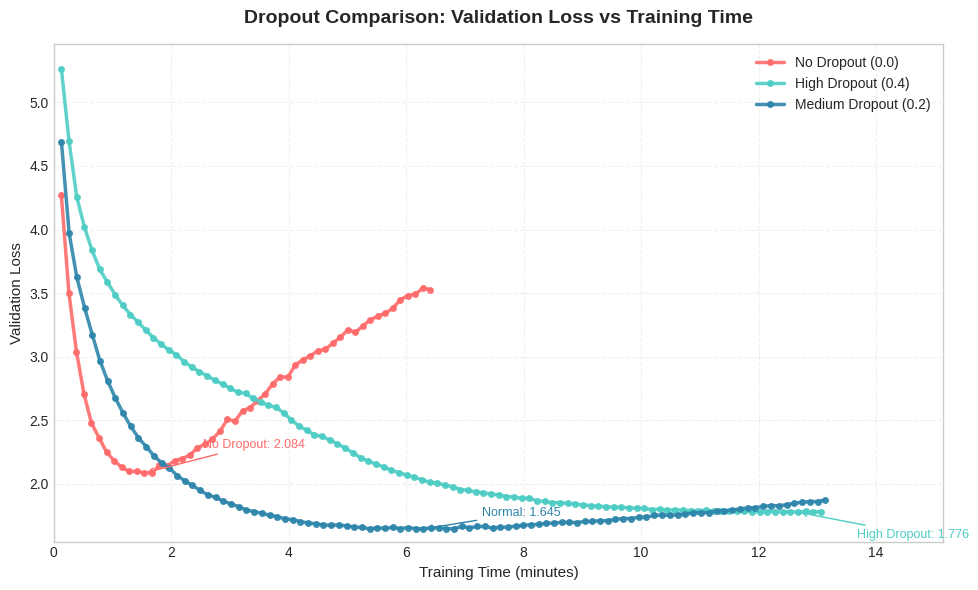

In [96]:
cum_time_no_dropout = np.cumsum(without_dropout_times) / 60
cum_time_high_dropout = np.cumsum(high_dropout_times) / 60
cum_time_simple = np.cumsum(simple_times) / 60

plt.figure(figsize=(10, 6))

plt.plot(cum_time_no_dropout, without_dropout_loss, 
         linewidth=2.5, 
         color='#FF6B6B', 
         marker='o', 
         markersize=4,
         label='No Dropout (0.0)',
         alpha=0.9)

plt.plot(cum_time_high_dropout, high_dropout_loss, 
         linewidth=2.5, 
         color='#4ECDC4', 
         marker='o', 
         markersize=4,
         label='High Dropout (0.4)',
         alpha=0.9)

plt.plot(cum_time_simple, simple_loss, 
         linewidth=2.5, 
         color='#2E86AB', 
         marker='o', 
         markersize=4,
         label='Medium Dropout (0.2)',
         alpha=0.9)

min_loss_no_dropout = min(without_dropout_loss)
min_time_no_dropout = cum_time_no_dropout[without_dropout_loss.index(min_loss_no_dropout)]

min_loss_high_dropout = min(high_dropout_loss)
min_time_high_dropout = cum_time_high_dropout[high_dropout_loss.index(min_loss_high_dropout)]

min_loss_simple = min(simple_loss)
min_time_simple = cum_time_simple[simple_loss.index(min_loss_simple)]

plt.annotate(f'No Dropout: {min_loss_no_dropout:.3f}', 
             xy=(min_time_no_dropout, min_loss_no_dropout), 
             xytext=(min_time_no_dropout + 1, min_loss_no_dropout + 0.2),
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1),
             fontsize=9, color='#FF6B6B')

plt.annotate(f'High Dropout: {min_loss_high_dropout:.3f}', 
             xy=(min_time_high_dropout, min_loss_high_dropout), 
             xytext=(min_time_high_dropout + 1, min_loss_high_dropout - 0.2),
             arrowprops=dict(arrowstyle='->', color='#4ECDC4', lw=1),
             fontsize=9, color='#4ECDC4')

plt.annotate(f'Normal: {min_loss_simple:.3f}', 
             xy=(min_time_simple, min_loss_simple), 
             xytext=(min_time_simple + 1, min_loss_simple + 0.1),
             arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1),
             fontsize=9, color='#2E86AB')

plt.title('Dropout Comparison: Validation Loss vs Training Time', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Time (minutes)', fontsize=11)
plt.ylabel('Validation Loss', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

plt.xlim(0, max(cum_time_no_dropout[-1], cum_time_high_dropout[-1], cum_time_simple[-1]) + 2)
plt.ylim(min(min_loss_no_dropout, min_loss_high_dropout, min_loss_simple) - 0.1, 
         max(without_dropout_loss[0], high_dropout_loss[0], simple_loss[0]) + 0.2)

plt.tight_layout()
plt.savefig('dropout.pdf', 
            format='pdf', 
            bbox_inches='tight',
            pad_inches=0.1,
            transparent=False)
plt.show()

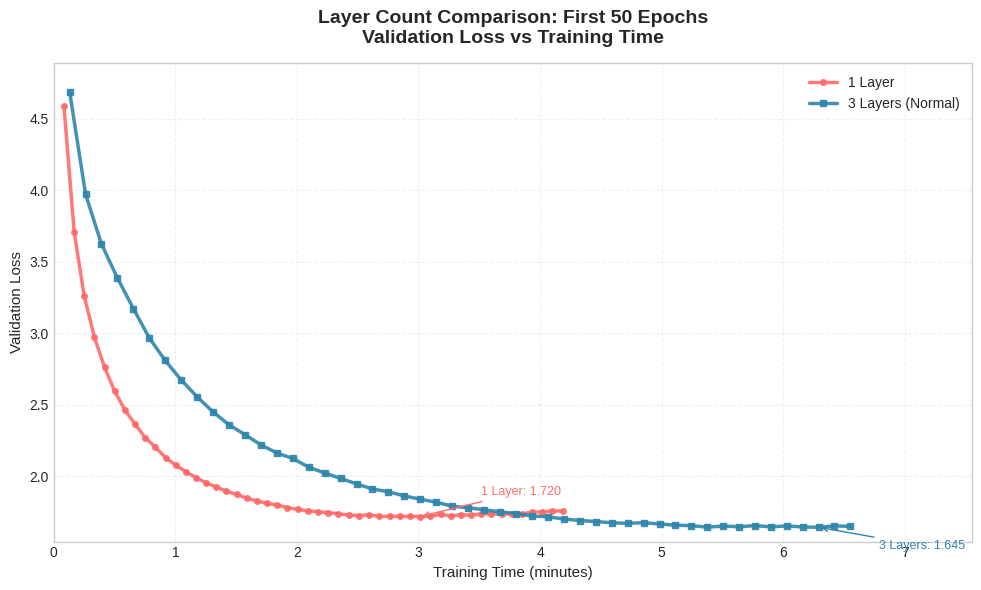

In [101]:
n_points = 50

one_layer_loss_50 = one_layer_loss[:n_points]
one_layer_times_50 = one_layer_times[:n_points]

simple_loss_50 = simple_loss[:n_points] 
simple_times_50 = simple_times[:n_points]

cum_time_one_layer = np.cumsum(one_layer_times_50) / 60
cum_time_simple = np.cumsum(simple_times_50) / 60

plt.figure(figsize=(10, 6))

plt.plot(cum_time_one_layer, one_layer_loss_50, 
         linewidth=2.5, 
         color='#FF6B6B', 
         marker='o', 
         markersize=4,
         label='1 Layer',
         alpha=0.9)

plt.plot(cum_time_simple, simple_loss_50, 
         linewidth=2.5, 
         color='#2E86AB', 
         marker='s', 
         markersize=4,
         label=f'{N_LAYERS} Layers (Normal)',
         alpha=0.9)

min_loss_one_layer = min(one_layer_loss_50)
min_time_one_layer = cum_time_one_layer[one_layer_loss_50.index(min_loss_one_layer)]

min_loss_simple = min(simple_loss_50)
min_time_simple = cum_time_simple[simple_loss_50.index(min_loss_simple)]

plt.annotate(f'1 Layer: {min_loss_one_layer:.3f}', 
             xy=(min_time_one_layer, min_loss_one_layer), 
             xytext=(min_time_one_layer + 0.5, min_loss_one_layer + 0.15),
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1),
             fontsize=9, color='#FF6B6B')

plt.annotate(f'{N_LAYERS} Layers: {min_loss_simple:.3f}', 
             xy=(min_time_simple, min_loss_simple), 
             xytext=(min_time_simple + 0.5, min_loss_simple - 0.15),
             arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1),
             fontsize=9, color='#2E86AB')

plt.title(f'Layer Count Comparison: First {n_points} Epochs\nValidation Loss vs Training Time', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Time (minutes)', fontsize=11)
plt.ylabel('Validation Loss', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

max_time = max(cum_time_one_layer[-1], cum_time_simple[-1])
max_loss = max(one_layer_loss_50[0], simple_loss_50[0])
min_loss = min(min_loss_one_layer, min_loss_simple)

plt.xlim(0, max_time + 1)
plt.ylim(min_loss - 0.1, max_loss + 0.2)

plt.tight_layout()
plt.savefig('layers.pdf', 
            format='pdf', 
            bbox_inches='tight',
            pad_inches=0.1,
            transparent=False)
plt.show()

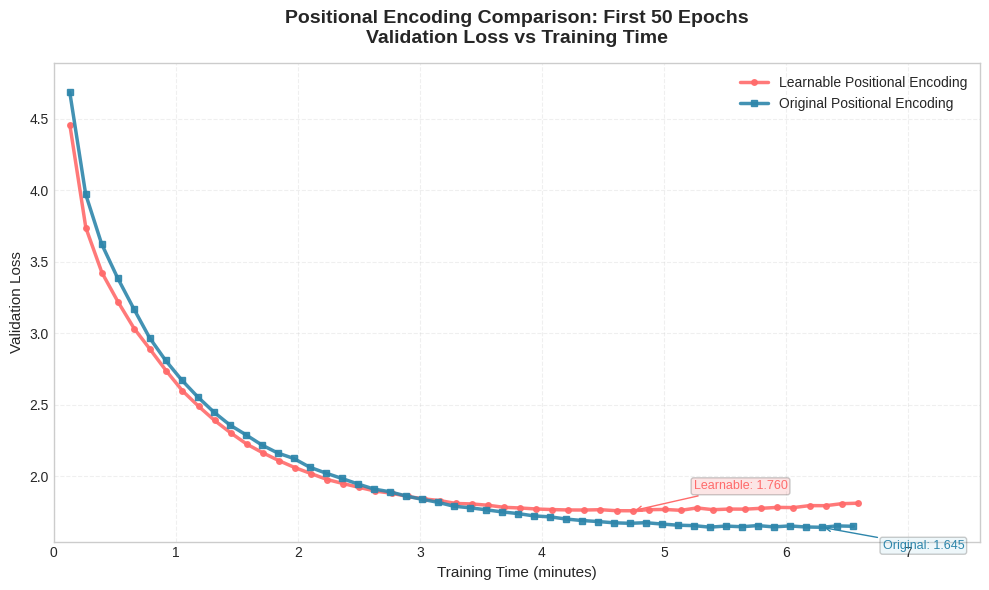

In [115]:
n_points = 50

learnablePE_loss_50 = leanablePE_simple_loss[:n_points]
learnablePE_times_50 = learnablePE_simple_times[:n_points]

simple_loss_50 = simple_loss[:n_points] 
simple_times_50 = simple_times[:n_points]

cum_time_learnable = np.cumsum(learnablePE_times_50) / 60
cum_time_simple = np.cumsum(simple_times_50) / 60

plt.figure(figsize=(10, 6))

plt.plot(cum_time_learnable, learnablePE_loss_50, 
         linewidth=2.5, 
         color='#FF6B6B', 
         marker='o', 
         markersize=4,
         label='Learnable Positional Encoding',
         alpha=0.9)

plt.plot(cum_time_simple, simple_loss_50, 
         linewidth=2.5, 
         color='#2E86AB', 
         marker='s', 
         markersize=4,
         label='Original Positional Encoding',
         alpha=0.9)

min_loss_learnable = min(learnablePE_loss_50)
min_time_learnable = cum_time_learnable[learnablePE_loss_50.index(min_loss_learnable)]

min_loss_simple = min(simple_loss_50)
min_time_simple = cum_time_simple[simple_loss_50.index(min_loss_simple)]

plt.annotate(f'Learnable: {min_loss_learnable:.3f}', 
             xy=(min_time_learnable, min_loss_learnable), 
             xytext=(min_time_learnable + 0.5, min_loss_learnable + 0.15),
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1),
             fontsize=9, color='#FF6B6B',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="lightcoral", alpha=0.2))

plt.annotate(f'Original: {min_loss_simple:.3f}', 
             xy=(min_time_simple, min_loss_simple), 
             xytext=(min_time_simple + 0.5, min_loss_simple - 0.15),
             arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1),
             fontsize=9, color='#2E86AB',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="lightblue", alpha=0.2))

plt.title(f'Positional Encoding Comparison: First {n_points} Epochs\nValidation Loss vs Training Time', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Time (minutes)', fontsize=11)
plt.ylabel('Validation Loss', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

max_time = max(cum_time_learnable[-1], cum_time_simple[-1])
max_loss = max(learnablePE_loss_50[0], simple_loss_50[0])
min_loss = min(min_loss_learnable, min_loss_simple)

plt.xlim(0, max_time + 1)
plt.ylim(min_loss - 0.1, max_loss + 0.2)

plt.tight_layout()
plt.savefig('pe.pdf', 
            format='pdf', 
            bbox_inches='tight',
            pad_inches=0.1,
            transparent=False)
plt.show()

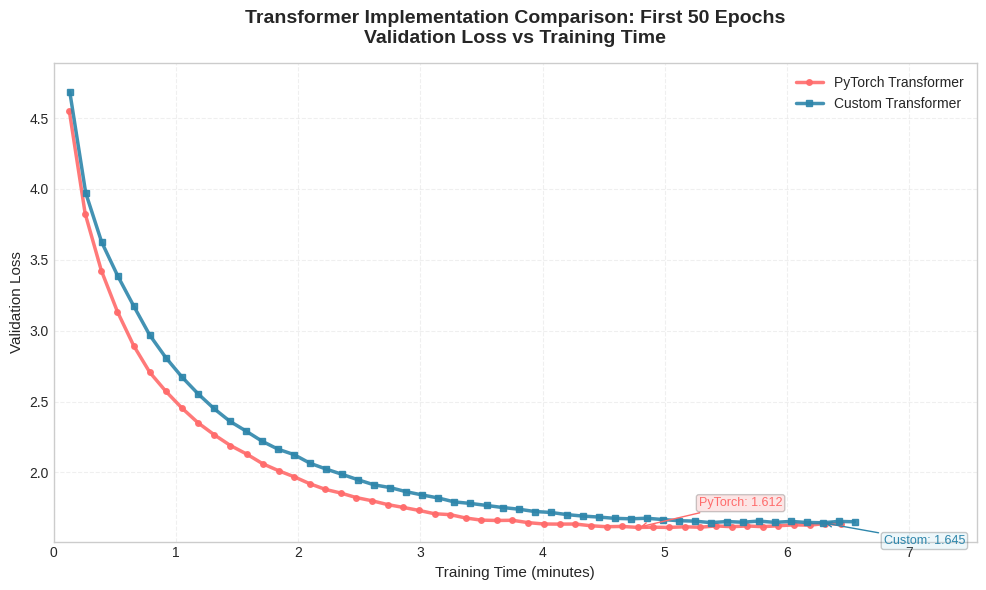

In [118]:
n_points = 50

torch_loss_50 = torch_loss[:n_points]
torch_times_50 = torch_times[:n_points]

simple_loss_50 = simple_loss[:n_points] 
simple_times_50 = simple_times[:n_points]

cum_time_torch = np.cumsum(torch_times_50) / 60
cum_time_simple = np.cumsum(simple_times_50) / 60

plt.figure(figsize=(10, 6))

plt.plot(cum_time_torch, torch_loss_50, 
         linewidth=2.5, 
         color='#FF6B6B', 
         marker='o', 
         markersize=4,
         label='PyTorch Transformer',
         alpha=0.9)

plt.plot(cum_time_simple, simple_loss_50, 
         linewidth=2.5, 
         color='#2E86AB', 
         marker='s', 
         markersize=4,
         label='Custom Transformer',
         alpha=0.9)

min_loss_torch = min(torch_loss_50)
min_time_torch = cum_time_torch[torch_loss_50.index(min_loss_torch)]

min_loss_simple = min(simple_loss_50)
min_time_simple = cum_time_simple[simple_loss_50.index(min_loss_simple)]

plt.annotate(f'PyTorch: {min_loss_torch:.3f}', 
             xy=(min_time_torch, min_loss_torch), 
             xytext=(min_time_torch + 0.5, min_loss_torch + 0.15),
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1),
             fontsize=9, color='#FF6B6B',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="lightcoral", alpha=0.2))

plt.annotate(f'Custom: {min_loss_simple:.3f}', 
             xy=(min_time_simple, min_loss_simple), 
             xytext=(min_time_simple + 0.5, min_loss_simple - 0.15),
             arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1),
             fontsize=9, color='#2E86AB',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="lightblue", alpha=0.2))

plt.title(f'Transformer Implementation Comparison: First {n_points} Epochs\nValidation Loss vs Training Time', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Time (minutes)', fontsize=11)
plt.ylabel('Validation Loss', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

max_time = max(cum_time_torch[-1], cum_time_simple[-1])
max_loss = max(torch_loss_50[0], simple_loss_50[0])
min_loss = min(min_loss_torch, min_loss_simple)

plt.xlim(0, max_time + 1)
plt.ylim(min_loss - 0.1, max_loss + 0.2)

plt.tight_layout()
plt.savefig('torch.pdf', 
            format='pdf', 
            bbox_inches='tight',
            pad_inches=0.1,
            transparent=False)
plt.show()

In [15]:
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt')))

test_loss = evaluate(model, test_dataloader, criterion)
print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')

def translate_sentence(sentence, model, max_len=50):
    model.eval()
    if isinstance(sentence, str):
        tokens = [tok.text for tok in spacy_de.tokenizer(sentence)]
    else:
        tokens = sentence
        
    tokens = [special_symbols[BOS_IDX]] + tokens + [special_symbols[EOS_IDX]]
    src_indexes = [vocab_src[token] for token in tokens]
    
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)
    src_mask = model.make_src_mask(src_tensor)
    
    with torch.no_grad():
        enc_src = model.encoder(src_tensor, src_mask)
        
    trg_indexes = [vocab_tgt[special_symbols[BOS_IDX]]]
    
    for i in range(max_len):
        trg_tensor = torch.LongTensor(trg_indexes).unsqueeze(0).to(device)
        trg_mask = model.make_trg_mask(trg_tensor)
        
        with torch.no_grad():
            output = model.decoder(trg_tensor, enc_src, src_mask, trg_mask)
            
        pred_token = output.argmax(2)[:, -1].item()
        trg_indexes.append(pred_token)
        
        if pred_token == vocab_tgt[special_symbols[EOS_IDX]]:
            break
            
    trg_tokens = [vocab_tgt.lookup_token(i) for i in trg_indexes]
    return trg_tokens[1:-1]

idx = 10
src_sample = dataset['test'][idx][SRC_LANGUAGE]
tgt_sample = dataset['test'][idx][TGT_LANGUAGE]

print(f'Source: {src_sample}')
print(f'Target: {tgt_sample}')

translation = translate_sentence(src_sample, model)
print(f'Predicted: {" ".join(translation)}')

| Test Loss: 1.752 | Test PPL:   5.766 |
Source: Eine Mutter und ihr kleiner Sohn genießen einen schönen Tag im Freien.
Target: A mother and her young song enjoying a beautiful day outside.
Predicted: A mother and her little son enjoy a beautiful day .
